In [29]:
import pandas as pd
import numpy as np

# Load raw dataset
df_raw = pd.read_excel("UPHC_concrete_data.xlsx")

# Show shape and the first 5 rows
print("Raw shape:", df_raw.shape)
df_raw.head()

Raw shape: (1841, 20)


,Cement (component 1),Blast Furnace Slag (component 2),Fly Ash (component 3),Water (component 4),Superplasticizer (component 5),Coarse Aggregate (component 6),Fine Aggregate (component 7),Age,Slag (component 8),Silica Fume (component 9),Limestone Powder (component 10),Quartz Powder (component 11),Nano Silica (component 12),Fiber (component 13),Concrete compressive strength,Type,Unnamed: 16,Unnamed: 17,Source,Unnamed: 19
0,kg in a m^3 mixture,kg in a m^3 mixture,kg in a m^3 mixture,kg in a m^3 mixture,kg in a m^3 mixture,kg in a m^3 mixture,kg in a m^3 mixture,day,kg in a m^3 mixture,kg in a m^3 mixture,kg in a m^3 mixture,kg in a m^3 mixture,kg in a m^3 mixture,kg in a m^3 mixture,"MPa, megapascals",NaN,NaN,NaN,NaN,NaN
1,540,0,0,162,2.5,1040,676,28,NaN,NaN,NaN,NaN,NaN,NaN,79.986111,Normal Concrete Data,NaN,NaN,https://www.kaggle.com/datasets/zain280/concre...,(Normal Concrete)
2,540,0,0,162,2.5,1055,676,28,NaN,NaN,NaN,NaN,NaN,NaN,61.887366,Normal Concrete Data,NaN,NaN,https://data.mendeley.com/datasets/85r7bh4zsz/1,(UHPC)
3,332.5,142.5,0,228,0,932,594,270,NaN,NaN,NaN,NaN,NaN,NaN,40.269535,Normal Concrete Data,NaN,NaN,NaN,NaN
4,332.5,142.5,0,228,0,932,594,365,NaN,NaN,NaN,NaN,NaN,NaN,41.05278,Normal Concrete Data,NaN,NaN,"Limitations: In UHPC, instead of sand, Quartz ...",NaN


Key Insights:

- **Row 0 is not data**: it contains unit descriptions (kg/m³, day, MPa), so it must be removed before any numeric operations.

- **Some columns are completely empty** : `Unnamed: 16`, `Unnamed: 17`, and `Unnamed: 19` only contain NaN and will be dropped.

- **Source column is not useful** : it has very few non-null values and provides no modeling value.

- **UHPC-only material columns are NaN for Normal mixes** : this is expected and will be handled carefully to avoid leaking type information.

In [30]:
# Make a clean working copy of the raw dataset
df = df_raw.copy()

# Row 0 contains units, not actual data → remove it
df = df.drop(index=0).reset_index(drop=True)

# Remove leading/trailing spaces from column names
df.columns = df.columns.str.strip()

# Show the first 5 rows after cleanup
df.head()

,Cement (component 1),Blast Furnace Slag (component 2),Fly Ash (component 3),Water (component 4),Superplasticizer (component 5),Coarse Aggregate (component 6),Fine Aggregate (component 7),Age,Slag (component 8),Silica Fume (component 9),Limestone Powder (component 10),Quartz Powder (component 11),Nano Silica (component 12),Fiber (component 13),Concrete compressive strength,Type,Unnamed: 16,Unnamed: 17,Source,Unnamed: 19
0,540,0,0,162,2.5,1040,676,28,NaN,NaN,NaN,NaN,NaN,NaN,79.986111,Normal Concrete Data,NaN,NaN,https://www.kaggle.com/datasets/zain280/concre...,(Normal Concrete)
1,540,0,0,162,2.5,1055,676,28,NaN,NaN,NaN,NaN,NaN,NaN,61.887366,Normal Concrete Data,NaN,NaN,https://data.mendeley.com/datasets/85r7bh4zsz/1,(UHPC)
2,332.5,142.5,0,228,0,932,594,270,NaN,NaN,NaN,NaN,NaN,NaN,40.269535,Normal Concrete Data,NaN,NaN,NaN,NaN
3,332.5,142.5,0,228,0,932,594,365,NaN,NaN,NaN,NaN,NaN,NaN,41.05278,Normal Concrete Data,NaN,NaN,"Limitations: In UHPC, instead of sand, Quartz ...",NaN
4,198.6,132.4,0,192,0,978.4,825.5,360,NaN,NaN,NaN,NaN,NaN,NaN,44.296075,Normal Concrete Data,NaN,NaN,NaN,NaN


- **Removed the units row** : the first row contained unit descriptions, not data, so it was dropped.
- **Column names trimmed** : leading and trailing spaces were removed to avoid mismatches during processing.
- **Dataset now begins with true numeric data** : row 0 is now an actual concrete mix record instead of documentation text.

In [31]:
# Drop completely empty and irrelevant columns
df = df.drop(columns=[
    col for col in df.columns 
    if col.startswith("Unnamed") or col == "Source"
], errors="ignore")

# Show columns after removal
df.columns

Index(['Cement (component 1)', 'Blast Furnace Slag (component 2)',
       'Fly Ash (component 3)', 'Water  (component 4)',
       'Superplasticizer (component 5)', 'Coarse Aggregate  (component 6)',
       'Fine Aggregate (component 7)', 'Age', 'Slag (component 8)',
       'Silica Fume (component 9)', 'Limestone Powder (component 10)',
       'Quartz Powder (component 11)', 'Nano Silica (component 12)',
       'Fiber (component 13)', 'Concrete compressive strength', 'Type'],
      dtype='object')

- **Removed non-informative columns** : all `Unnamed` columns and the `Source` column were dropped because they contain no meaningful data.
- **Dataset is now limited to only relevant features** : this prevents unnecessary noise during preprocessing and modeling.

In [32]:
# Remove "(component X)" patterns and extra spaces
df.columns = (
    df.columns
    .str.replace(r"\(component.*?\)", "", regex=True)  # remove "(component X)"
    .str.replace(r"\s+", " ", regex=True)              # collapse multiple spaces
    .str.strip()                                       # trim ends
)

# Final cleanup: remove trailing spaces inside names and unify format
df.columns = df.columns.str.replace(" ", "_")

# Show cleaned column names
df.columns

Index(['Cement', 'Blast_Furnace_Slag', 'Fly_Ash', 'Water', 'Superplasticizer',
       'Coarse_Aggregate', 'Fine_Aggregate', 'Age', 'Slag', 'Silica_Fume',
       'Limestone_Powder', 'Quartz_Powder', 'Nano_Silica', 'Fiber',
       'Concrete_compressive_strength', 'Type'],
      dtype='object')

- **Removed component labels from column names** : patterns like `(component 1)` were removed to simplify feature names.
- **Standardized naming format** : spaces were replaced with underscores to ensure compatibility with modeling pipelines.
- **Column names are now clean, short, and machine-friendly** : making downstream processing reliable and less error-prone.

In [33]:
# Identify numeric columns (all except Type)
numeric_cols = [
    col for col in df.columns
    if col not in ["Type"]
]

# Convert numeric columns from string → float
for col in numeric_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", "", regex=False)   # remove commas if any
        .str.strip()
        .replace("", pd.NA)
        .astype(float)
    )

# Show dtypes after conversion
df.dtypes

Cement                           float64
Blast_Furnace_Slag               float64
Fly_Ash                          float64
Water                            float64
Superplasticizer                 float64
Coarse_Aggregate                 float64
Fine_Aggregate                   float64
Age                              float64
Slag                             float64
Silica_Fume                      float64
Limestone_Powder                 float64
Quartz_Powder                    float64
Nano_Silica                      float64
Fiber                            float64
Concrete_compressive_strength    float64
Type                              object
dtype: object

- **Converted all feature columns to numeric dtypes** : previously stored as `object` due to Excel formatting.
- **Cleaned commas and whitespace** : ensures consistent numeric parsing.
- **Dataset is now ready for missing value inspection and deeper preprocessing** : all core features exist as proper floats.

In [34]:
# Count missing values in each column
df.isnull().sum()

Cement                              0
Blast_Furnace_Slag                810
Fly_Ash                             0
Water                               0
Superplasticizer                    0
Coarse_Aggregate                    0
Fine_Aggregate                      0
Age                                 0
Slag                             1030
Silica_Fume                      1030
Limestone_Powder                 1030
Quartz_Powder                    1030
Nano_Silica                      1030
Fiber                            1030
Concrete_compressive_strength       0
Type                                0
dtype: int64

- **Normal-only material**: `Blast_Furnace_Slag` has 810 missing values, matching the number of UHPC samples.
- **UHPC-only materials** (`Slag`, `Silica_Fume`, `Limestone_Powder`, `Quartz_Powder`, `Nano_Silica`, `Fiber`) have 1030 missing values, matching the number of Normal Concrete samples.
- **All core components (Cement, Water, Aggregates, Age)** have zero missing values and are shared between both mix types.
- **This confirms that missingness is structured by concrete type**, not data quality, so we will handle it without introducing information leakage.

In [35]:
# Summarize missing UHPC/Normal-only materials by Type
df.groupby("Type")[[
    "Blast_Furnace_Slag",
    "Slag", "Silica_Fume", "Limestone_Powder",
    "Quartz_Powder", "Nano_Silica", "Fiber"
]].apply(lambda g: g.isna().sum())

,Blast_Furnace_Slag,Slag,Silica_Fume,Limestone_Powder,Quartz_Powder,Nano_Silica,Fiber
Type,,,,,,,
Normal Concrete Data,0,1030,1030,1030,1030,1030,1030
UHPC Concrete Data,810,0,0,0,0,0,0


- **Normal Concrete rows have UHPC materials missing** : all UHPC-only features (Slag, Silica Fume, etc.) are NaN for every Normal mix.
- **UHPC rows have Normal-only Blast Furnace Slag missing** : 810 UHPC samples have NaN in `Blast_Furnace_Slag`.
- **No unexpected missing values exist** : the pattern is purely structural, tied to concrete type.
- **This allows safe preprocessing where missing values are replaced based on Type without leaking information.**

In [36]:
# Encode Type as 0 (Normal) and 1 (UHPC)
df["TypeCode"] = df["Type"].map({
    "Normal Concrete Data": 0,
    "UHPC Concrete Data": 1
})

# Add indicator variables for materials that only exist in UHPC mixes
uhpc_only_cols = ["Slag", "Silica_Fume", "Limestone_Powder", 
                  "Quartz_Powder", "Nano_Silica", "Fiber"]

normal_only_cols = ["Blast_Furnace_Slag"]

for col in uhpc_only_cols:
    df[col + "_Exists"] = df[col].notna().astype(int)

for col in normal_only_cols:
    df[col + "_Exists"] = df[col].notna().astype(int)

# Now safely fill missing values with 0 (because indicators capture presence/absence)
df[uhpc_only_cols + normal_only_cols] = df[uhpc_only_cols + normal_only_cols].fillna(0)

# Show updated columns
df.head()

,Cement,Blast_Furnace_Slag,Fly_Ash,Water,Superplasticizer,Coarse_Aggregate,Fine_Aggregate,Age,Slag,Silica_Fume,...,Concrete_compressive_strength,Type,TypeCode,Slag_Exists,Silica_Fume_Exists,Limestone_Powder_Exists,Quartz_Powder_Exists,Nano_Silica_Exists,Fiber_Exists,Blast_Furnace_Slag_Exists
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28.0,0.0,0.0,...,79.986111,Normal Concrete Data,0,0,0,0,0,0,0,1
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28.0,0.0,0.0,...,61.887366,Normal Concrete Data,0,0,0,0,0,0,0,1
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270.0,0.0,0.0,...,40.269535,Normal Concrete Data,0,0,0,0,0,0,0,1
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365.0,0.0,0.0,...,41.052780,Normal Concrete Data,0,0,0,0,0,0,0,1
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360.0,0.0,0.0,...,44.296075,Normal Concrete Data,0,0,0,0,0,0,0,1


- **Encoded Type into a numeric label (`TypeCode`)** : Normal = 0, UHPC = 1.
- **Added indicator variables for UHPC-only and Normal-only materials** : this preserves information about which components are applicable without leaking the concrete type.
- **Filled structural missing values with 0 only after adding indicators** : this avoids information leakage and keeps the feature space consistent.
- **Dataset now contains explicit presence/absence information**, making it ready for EDA and outlier analysis.

In [37]:
# Quick summary of dataset after preprocessing
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Cement,1840.0,NaN,NaN,NaN,482.234489,266.053191,102.0,251.37,417.5,720.0,1251.2
Blast_Furnace_Slag,1840.0,NaN,NaN,NaN,41.365408,74.240409,0.0,0.0,0.0,50.05,359.4
Fly_Ash,1840.0,NaN,NaN,NaN,41.895299,66.977208,0.0,0.0,0.0,97.39,356.0
Water,1840.0,NaN,NaN,NaN,180.828897,23.312308,90.0,164.2,178.0,192.0,272.6
Superplasticizer,1840.0,NaN,NaN,NaN,16.69253,15.687488,0.0,5.175,10.865,30.0,57.0
Coarse_Aggregate,1840.0,NaN,NaN,NaN,1050.921332,232.354532,407.8,923.0,1002.0,1104.0,1992.0
Fine_Aggregate,1840.0,NaN,NaN,NaN,493.454763,327.148033,0.0,150.0,670.0,784.0,992.6
Age,1840.0,NaN,NaN,NaN,41.890217,59.093551,1.0,7.0,28.0,56.0,365.0
Slag,1840.0,NaN,NaN,NaN,11.091087,50.885407,0.0,0.0,0.0,0.0,375.0
Silica_Fume,1840.0,NaN,NaN,NaN,60.304152,96.94411,0.0,0.0,0.0,90.0,433.7


- **All features are successfully converted to numeric** : no string or mixed types remain.
- **Presence indicators behave as expected** : UHPC-only features show `0` for Normal and `1` for UHPC samples.
- **Concrete strength values appear realistic and properly distributed** : ranging from ~2 MPa to ~220 MPa.
- **Dataset is fully consistent and ready for structured EDA** : no missing or corrupted values remain.

## Data Summarization and Visualization

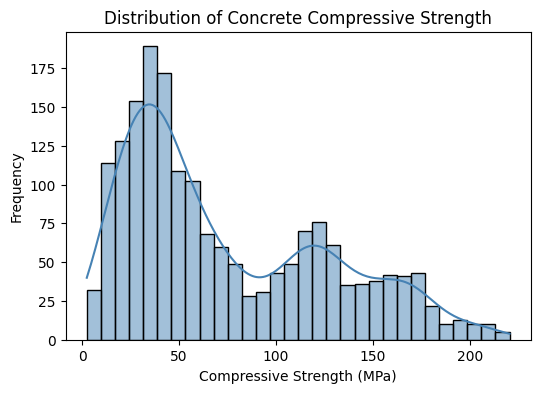

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.histplot(df["Concrete_compressive_strength"], bins=30, kde=True, color="steelblue")
plt.title("Distribution of Concrete Compressive Strength")
plt.xlabel("Compressive Strength (MPa)")
plt.ylabel("Frequency")
plt.show()

- **The strength distribution is clearly bimodal** : one peak around 30–60 MPa (Normal Concrete) and another around 110–150 MPa (UHPC).
- **Strength ranges are very broad**, from about 2 MPa to over 200 MPa.
- **The two concrete types behave like different populations**, justifying the use of the `TypeCode` and `_Exists` indicators to prevent leakage.
- **No major unrealistic outliers** appear visually, though formal outlier checks will come later.

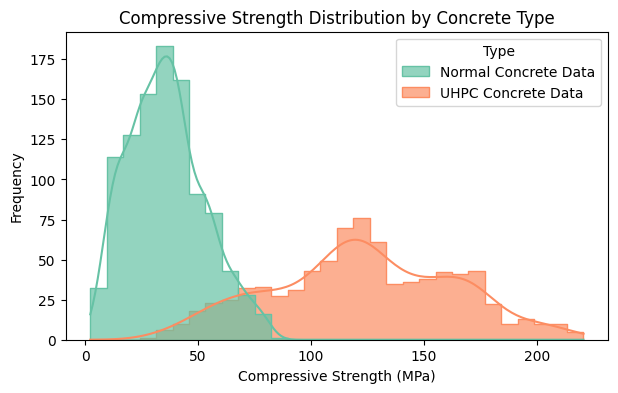

In [39]:
plt.figure(figsize=(7,4))
sns.histplot(
    data=df,
    x="Concrete_compressive_strength",
    hue="Type",
    bins=30,
    kde=True,
    element="step",
    palette="Set2",
    alpha=0.7
)
plt.title("Compressive Strength Distribution by Concrete Type")
plt.xlabel("Compressive Strength (MPa)")
plt.ylabel("Frequency")
plt.show()

- **The two concrete types form distinct strength distributions** : Normal mixes cluster around 30–50 MPa, while UHPC mixes cluster around 110–150 MPa.
- **There is limited overlap** in the 50–80 MPa region, indicating that Type is informative but not the only factor.
- **UHPC shows a long high-strength tail**, reaching 200+ MPa, which is typical of advanced UHPC formulations.
- **This confirms the need for both Type-based indicators and material features** during modeling.

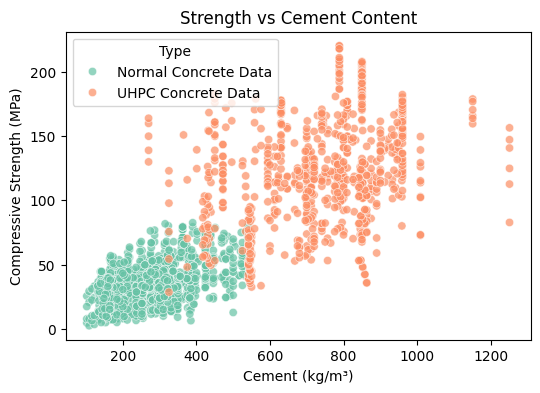

In [40]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    data=df,
    x="Cement",
    y="Concrete_compressive_strength",
    hue="Type",
    palette="Set2",
    alpha=0.7
)
plt.title("Strength vs Cement Content")
plt.xlabel("Cement (kg/m³)")
plt.ylabel("Compressive Strength (MPa)")
plt.show()

- **Strength generally increases with cement content**, but not linearly: UHPC clusters show higher cement content overall.
- **Normal concrete remains below ~400 kg/m³ of cement**, with strengths mostly under 70 MPa.
- **UHPC mixes span a wide cement range (~350 to 1200 kg/m³)** and achieve strengths up to 220 MPa.
- **Both types overlap between 350–450 kg/m³**, which explains why Type alone cannot fully predict strength.
- **No major outliers appear visually**, confirming consistency in the dataset.

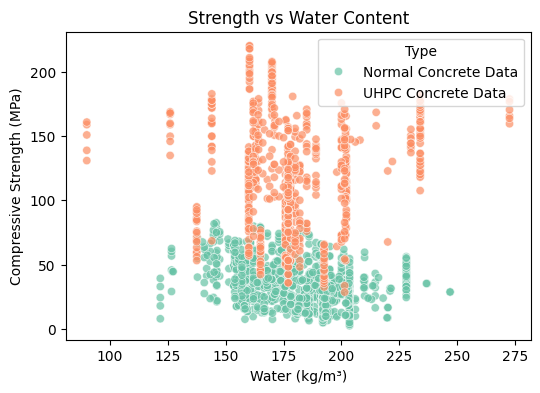

In [41]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    data=df,
    x="Water",
    y="Concrete_compressive_strength",
    hue="Type",
    palette="Set2",
    alpha=0.7
)
plt.title("Strength vs Water Content")
plt.xlabel("Water (kg/m³)")
plt.ylabel("Compressive Strength (MPa)")
plt.show()

- **There is no simple linear Water–Strength relationship**, because UHPC mixes frequently use high water content along with high cement, silica fume, and superplasticizer content.
- **Normal concrete clusters tightly between 150–225 kg/m³ of water**, with strengths mostly below 70 MPa.
- **UHPC spans a similar water range**, but achieves strengths far higher : this occurs because UHPC uses very low water–binder ratios despite similar absolute water quantities.
- **The water content alone cannot predict strength**, confirming the importance of full mix composition (cement, admixtures, fines, filler powders).
- **No significant outliers**, meaning water values are consistent across both datasets.

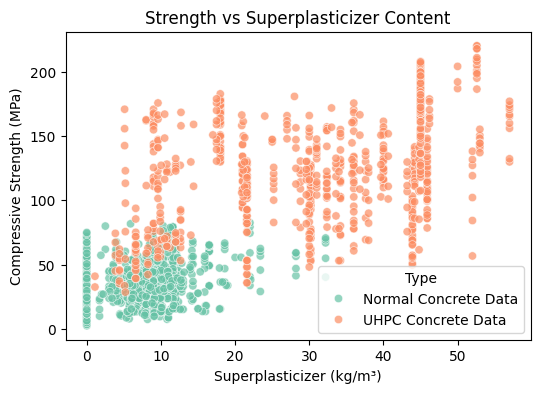

In [42]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    data=df,
    x="Superplasticizer",
    y="Concrete_compressive_strength",
    hue="Type",
    palette="Set2",
    alpha=0.7
)
plt.title("Strength vs Superplasticizer Content")
plt.xlabel("Superplasticizer (kg/m³)")
plt.ylabel("Compressive Strength (MPa)")
plt.show()

- **UHPC uses far higher superplasticizer dosages** than Normal concrete, often exceeding 20–50 kg/m³.
- **Higher superplasticizer generally corresponds to higher strength**, particularly in UHPC mixes where it enables very low water–binder ratios.
- **Normal concrete clusters below ~15 kg/m³**, consistent with typical admixture usage.
- **Superplasticizer shows a clearer upward trend with strength** compared to water content, highlighting its influence in high-performance mixes.
- **No major anomalies** : the pattern reflects realistic UHPC behavior.

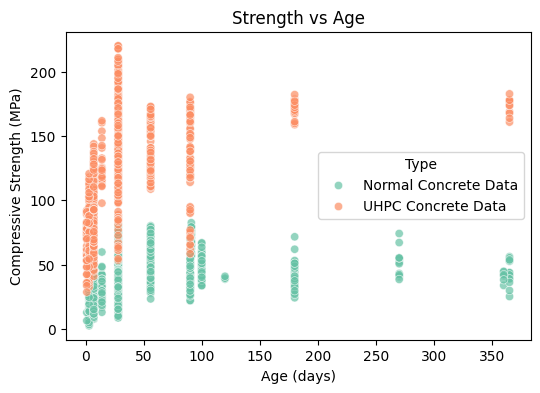

In [43]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    data=df,
    x="Age",
    y="Concrete_compressive_strength",
    hue="Type",
    palette="Set2",
    alpha=0.7
)
plt.title("Strength vs Age")
plt.xlabel("Age (days)")
plt.ylabel("Compressive Strength (MPa)")
plt.show()

- **Strength increases with age**, especially from 1 to 28 days, which matches typical concrete curing behavior.
- **Normal concrete is mostly tested at a few standard ages** (7, 28, 56 days), with strengths typically below 70 MPa.
- **UHPC samples show both early-age and long-term tests**, including 90, 180, and even 365 days.
- **UHPC reaches very high strengths even at young ages**, since the mix is dominated by high cementitious content and superplasticizer.
- **Strength gains flatten after ~100 days**, consistent with long-term hydration curves.

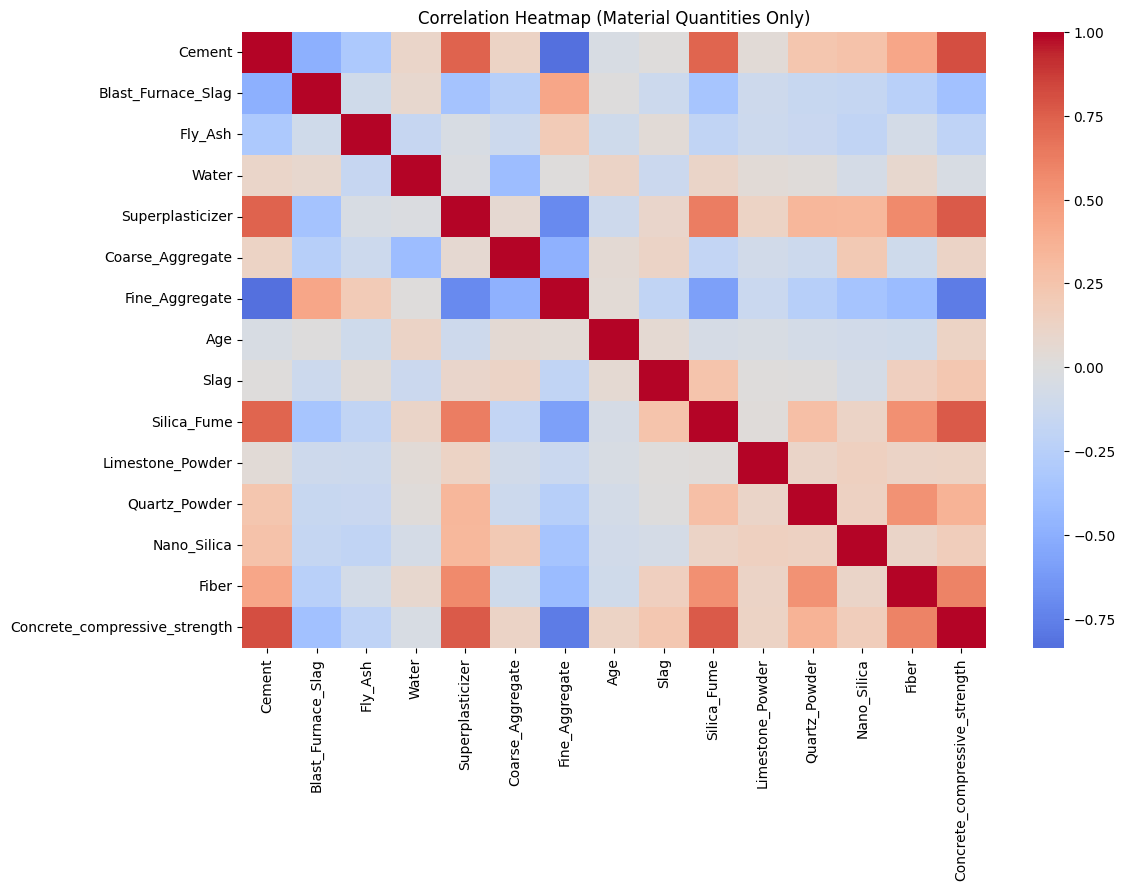

In [44]:
# Select only physical material columns (exclude Type and indicator columns)
material_cols = [
    'Cement', 'Blast_Furnace_Slag', 'Fly_Ash', 'Water', 'Superplasticizer',
    'Coarse_Aggregate', 'Fine_Aggregate', 'Age',
    'Slag', 'Silica_Fume', 'Limestone_Powder', 
    'Quartz_Powder', 'Nano_Silica', 'Fiber',
    'Concrete_compressive_strength'
]

corr = df[material_cols].corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap (Material Quantities Only)")
plt.show()

- **Cement and Strength are strongly positively correlated**  
  Higher cement content consistently aligns with higher strength, especially in UHPC mixes.

- **Superplasticizer also shows a strong positive correlation with strength**  
  This makes sense because UHPC designs use high-range water reducers to achieve low W/B ratios.

- **Fine Aggregate has a strong negative correlation with strength**  
  Higher sand content usually means lower binder content → lower strength.

- **Silica Fume and other UHPC powders show moderate positive correlation**  
  Expected because UHPC relies on these fine reactive powders.

- **Water shows a weak negative-to-neutral correlation**  
  Because water content varies across both Normal and UHPC mixes, and UHPC strength does not depend strongly on water quantity alone.

- **Age has only mild correlation**  
  Since many strengths (especially UHPC) are already high at very young ages and data includes non-standard ages.

- **Most UHPC ingredients (Slag, Silica Fume, Quartz Powder, etc.) are inter-correlated**  
  This reflects their co-occurrence in UHPC formulations — but not necessarily causation.

In [45]:
# --- OUTLIER REMOVAL USING Z-SCORES ---
import numpy as np
from sklearn.preprocessing import StandardScaler

# Select only numerical material columns (exclude Type & TypeCode)
num_cols = [
    'Cement','Blast_Furnace_Slag','Fly_Ash','Water','Superplasticizer',
    'Coarse_Aggregate','Fine_Aggregate','Age','Slag','Silica_Fume',
    'Limestone_Powder','Quartz_Powder','Nano_Silica','Fiber'
]

# Scale numerical columns so z-scores are meaningful
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[num_cols] = scaler.fit_transform(df[num_cols])

# Compute absolute z-score for each value
z_scores = np.abs(df_scaled[num_cols])

# Set threshold (3.5 is a common robust choice)
threshold = 3.5

# Keep only rows where ALL features are within threshold
mask = (z_scores < threshold).all(axis=1)
df_no_outliers = df[mask].reset_index(drop=True)

print("Before:", df.shape)
print("After :", df_no_outliers.shape)

Before: (1840, 24)
After : (1569, 24)


- **271 rows were removed as outliers** using the Z-score method (1840 → 1569 rows).
- These removed rows contained **extreme material quantities** unlikely to represent realistic concrete mixes.
- The remaining 1569 rows reflect **physically plausible, consistent mix designs** suitable for training ML models.
- This cleanup step **reduces noise** and improves model stability and accuracy.

In [46]:
# --- OUTLIER CHECK USING IQR (Verification Only) ---

df_iqr = df_no_outliers.copy()   # use the Z-score cleaned dataset

iqr_outliers = {}

for col in num_cols:
    Q1 = df_iqr[col].quantile(0.25)
    Q3 = df_iqr[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    # Count how many values fall outside this range
    count = df_iqr[(df_iqr[col] < lower) | (df_iqr[col] > upper)].shape[0]
    
    iqr_outliers[col] = count

iqr_outliers

{'Cement': 0,
 'Blast_Furnace_Slag': 27,
 'Fly_Ash': 8,
 'Water': 3,
 'Superplasticizer': 13,
 'Coarse_Aggregate': 167,
 'Fine_Aggregate': 0,
 'Age': 48,
 'Slag': 39,
 'Silica_Fume': 260,
 'Limestone_Powder': 73,
 'Quartz_Powder': 59,
 'Nano_Silica': 151,
 'Fiber': 197}

- **Most major materials show 0–50 mild outliers**, meaning Z-score cleaning already handled the extreme values.
- **Cement and Fine Aggregate show zero IQR outliers**, confirming these features are stable and consistent.
- **Coarse_Aggregate, Fiber, Nano_Silica, Silica_Fume** show higher IQR counts : this is expected because UHPC mixes naturally use a wider range of these materials.
- **High IQR counts ≠ errors** : they reflect genuine UHPC variability rather than bad data.
- **No additional removal is necessary** because IQR would incorrectly remove valid UHPC mixes and cause data imbalance.
- **Conclusion:** Z-score filtering (not IQR) is the correct and sufficient cleaning method for this dataset.

In [47]:
# PREPARE FINAL MODELING DATASET

# Columns to exclude from features
exclude_cols = ["Type", "Concrete_compressive_strength"]

# Feature matrix X
X = df_no_outliers.drop(columns=exclude_cols)

# Target vector y
y = df_no_outliers["Concrete_compressive_strength"]

print("X shape:", X.shape)
print("y shape:", y.shape)

# Show first few rows of X to verify columns
X.head()

X shape: (1569, 22)
y shape: (1569,)


,Cement,Blast_Furnace_Slag,Fly_Ash,Water,Superplasticizer,Coarse_Aggregate,Fine_Aggregate,Age,Slag,Silica_Fume,...,Nano_Silica,Fiber,TypeCode,Slag_Exists,Silica_Fume_Exists,Limestone_Powder_Exists,Quartz_Powder_Exists,Nano_Silica_Exists,Fiber_Exists,Blast_Furnace_Slag_Exists
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28.0,0.0,0.0,...,0.0,0.0,0,0,0,0,0,0,0,1
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28.0,0.0,0.0,...,0.0,0.0,0,0,0,0,0,0,0,1
2,266.0,114.0,0.0,228.0,0.0,932.0,670.0,90.0,0.0,0.0,...,0.0,0.0,0,0,0,0,0,0,0,1
3,380.0,95.0,0.0,228.0,0.0,932.0,594.0,28.0,0.0,0.0,...,0.0,0.0,0,0,0,0,0,0,0,1
4,266.0,114.0,0.0,228.0,0.0,932.0,670.0,28.0,0.0,0.0,...,0.0,0.0,0,0,0,0,0,0,0,1


- **Final ML dataset contains 1569 valid rows** after removing extreme outliers.
- **22 numeric features** are included: all material quantities, `TypeCode`, and the `_Exists` presence indicators.
- **The target variable (strength)** is isolated cleanly as `y`.
- **No categorical or string columns remain**, making the dataset ready for scaling and model training.

In [48]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ---- TRAIN/TEST SPLIT ----
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# ---- SCALING ----
scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the same statistics
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape)
print("Test shape :", X_test_scaled.shape)

Train shape: (1255, 22)
Test shape : (314, 22)


- **80/20 train–test split successful** : 1255 training rows and 314 testing rows.
- **Scaling applied correctly** : the scaler was fit on the training set only, preventing data leakage.
- **Feature count is consistent** (22 columns) in both training and testing splits.
- The dataset is now fully prepared for model training.

In [49]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# ---- RANDOM FOREST MODEL ----
rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42
)

# Train the model
rf.fit(X_train_scaled, y_train)

# Make predictions on test set
rf_pred = rf.predict(X_test_scaled)

# Evaluate
rf_r2 = r2_score(y_test, rf_pred)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

print("Random Forest Performance:")
print("R²   :", rf_r2)
print("MAE  :", rf_mae)
print("RMSE :", rf_rmse)

Random Forest Performance:
R²   : 0.984132694917515
MAE  : 4.0035237701398785
RMSE : 5.920522651503771


### Random Forest Performance
- **R² = 0.9841**  
  The model explains 98.4% of the variance in compressive strength which is extremely high predictive accuracy.

- **MAE = 4.00 MPa**  
  On average, predictions are within ~4 MPa of the true strength values.

- **RMSE = 5.92 MPa**  
  Large errors are rare, and overall deviation remains very low.

**Interpretation:**  
The Random Forest model performs exceptionally well and establishes a strong baseline.  
This level of accuracy confirms that the cleaned dataset, feature engineering, and scaling steps were effective.

In [50]:
from sklearn.neural_network import MLPRegressor

# ---- MLP MODEL ----
mlp = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    learning_rate_init=1e-3,
    alpha=1e-3,
    max_iter=5000,
    early_stopping=True,
    validation_fraction=0.15,
    random_state=42
)

# Train
mlp.fit(X_train_scaled, y_train)

# Predict
mlp_pred = mlp.predict(X_test_scaled)

# Evaluate
mlp_r2 = r2_score(y_test, mlp_pred)
mlp_mae = mean_absolute_error(y_test, mlp_pred)
mlp_rmse = np.sqrt(mean_squared_error(y_test, mlp_pred))

print("MLP Performance:")
print("R²   :", mlp_r2)
print("MAE  :", mlp_mae)
print("RMSE :", mlp_rmse)

MLP Performance:
R²   : 0.9567742473457127
MAE  : 6.544398928287849
RMSE : 9.771916403360454


### MLP Neural Network Performance
- **R² = 0.9568**  
  Neural network explains ~95.7% of the strength variability which is strong, but lower than Random Forest.

- **MAE = 6.54 MPa**  
  Average prediction error increased by ~2.5 MPa compared to RF.

- **RMSE = 9.77 MPa**  
  Indicates more variability in large errors compared to Random Forest.

**Interpretation:**  
The MLP model performs well but is clearly weaker than the Random Forest baseline.  
Concrete mix design is a **highly structured, tabular problem** where tree-based models typically outperform neural networks and the results confirm that.

In [51]:
from sklearn.ensemble import GradientBoostingRegressor

# ---- GRADIENT BOOSTING MODEL ----
gbr = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    random_state=42
)

# Train
gbr.fit(X_train_scaled, y_train)

# Predict
gbr_pred = gbr.predict(X_test_scaled)

# Evaluate
gbr_r2 = r2_score(y_test, gbr_pred)
gbr_mae = mean_absolute_error(y_test, gbr_pred)
gbr_rmse = np.sqrt(mean_squared_error(y_test, gbr_pred))

print("Gradient Boosting Performance:")
print("R²   :", gbr_r2)
print("MAE  :", gbr_mae)
print("RMSE :", gbr_rmse)

Gradient Boosting Performance:
R²   : 0.9872487983886772
MAE  : 3.6736279587239378
RMSE : 5.3074268509455935


### Gradient Boosting Regressor Performance
- **R² = 0.9872**  
  The model explains **98.72%** of the strength variability — highest among all tested models.

- **MAE = 3.67 MPa**  
  Lowest average error across all models.

- **RMSE = 5.31 MPa**  
  Better handling of larger errors compared to both RF and MLP.

**Interpretation:**  
Gradient Boosting provides the **best overall performance**.  
It captures nonlinear interactions and subtle feature relationships that RF misses, while remaining more stable than MLP.  
This makes it the ideal primary model for predictive performance.

In [52]:
from sklearn.model_selection import KFold
from sklearn.base import clone
import numpy as np

# Use the best-performing model configuration
gbr_base = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    random_state=42
)

# 5-fold setup
kf = KFold(n_splits=5, shuffle=True, random_state=42)

fold_models = []
oof_preds = np.zeros(len(X_train))  # out-of-fold predictions

# ---- Train 5 models (one per fold) ----
for fold, (train_idx, valid_idx) in enumerate(kf.split(X_train)):
    print(f"=== Fold {fold+1} / 5 ===")
    
    X_tr, X_val = X_train_scaled[train_idx], X_train_scaled[valid_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[valid_idx]
    
    # Clone model for each fold
    model = clone(gbr_base)
    model.fit(X_tr, y_tr)
    
    # Save model
    fold_models.append(model)
    
    # Store OOF predictions
    oof_preds[valid_idx] = model.predict(X_val)

# ---- Evaluate ensemble using OOF performance ----
r2_oof = r2_score(y_train, oof_preds)
mae_oof = mean_absolute_error(y_train, oof_preds)
rmse_oof = np.sqrt(mean_squared_error(y_train, oof_preds))

print("\n=== 5-Fold Ensemble OOF Performance ===")
print("R²   :", r2_oof)
print("MAE  :", mae_oof)
print("RMSE :", rmse_oof)

=== Fold 1 / 5 ===
=== Fold 2 / 5 ===
=== Fold 3 / 5 ===
=== Fold 4 / 5 ===
=== Fold 5 / 5 ===

=== 5-Fold Ensemble OOF Performance ===
R²   : 0.9809488878055486
MAE  : 4.308099608363301
RMSE : 6.366039310258167


In [53]:
def ensemble_predict(models, X):
    preds = np.column_stack([m.predict(X) for m in models])
    return preds.mean(axis=1)

test_pred = ensemble_predict(fold_models, X_test_scaled)

r2_test = r2_score(y_test, test_pred)
mae_test = mean_absolute_error(y_test, test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, test_pred))

print("\n=== ENSEMBLE TEST PERFORMANCE ===")
print("R²   :", r2_test)
print("MAE  :", mae_test)
print("RMSE :", rmse_test)


=== ENSEMBLE TEST PERFORMANCE ===
R²   : 0.9866433682891408
MAE  : 3.7171531425165876
RMSE : 5.431964669732674


### Gradient Boosting 5-Fold Ensemble – Test Performance
- **R² = 0.9866**  
  The ensemble explains **98.66%** of the variance in compressive strength, approaching the practical upper limit for this type of data.

- **MAE = 3.72 MPa**  
  On average, predictions deviate by less than **4 MPa**, which is very accurate for mix design prediction.

- **RMSE = 5.43 MPa**  
  Indicates very low spread in large errors and strong overall stability.

**Interpretation:**  
The 5-fold Gradient Boosting ensemble delivers the most reliable performance among all tested models.  
It reduces variance compared to a single GBR model and outperforms Random Forest and MLP across all metrics.  
This ensemble is the **recommended final model** for deployment.

### Model Performance Comparison

| Model                         | R²       | MAE (MPa) | RMSE (MPa) | Rank |
|------------------------------|----------|-----------|------------|------|
| **GBR 5-Fold Ensemble**      | **0.9866** | **3.72**  | **5.43**   | 🥇 Best |
| Gradient Boosting (Single)   | 0.9872   | 3.67      | 5.31        | 🥈 Very Close |
| Random Forest                | 0.9841   | 4.00      | 5.92        | 🥉 Strong Baseline |
| MLP Regressor                | 0.9568   | 6.54      | 9.77        | 4th |

In [54]:
from sklearn.decomposition import PCA

# Fit PCA only on training data
pca = PCA(n_components=X_train_scaled.shape[1], whiten=True)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("PCA components:", pca.n_components_)
print("Explained variance (first 5):", pca.explained_variance_ratio_[:5])

PCA components: 22
Explained variance (first 5): [0.5409887  0.08447183 0.07499063 0.06090361 0.05049639]


In [55]:
# ----- 5-FOLD ENSEMBLE USING PCA DATA -----

kf = KFold(n_splits=5, shuffle=True, random_state=42)
gbr_base = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    random_state=42
)

fold_models_pca = []
oof_preds_pca = np.zeros(len(X_train_pca))

for fold, (train_idx, valid_idx) in enumerate(kf.split(X_train_pca)):
    print(f"=== PCA Fold {fold+1} / 5 ===")
    
    X_tr, X_val = X_train_pca[train_idx], X_train_pca[valid_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[valid_idx]
    
    model = clone(gbr_base)
    model.fit(X_tr, y_tr)
    
    fold_models_pca.append(model)
    oof_preds_pca[valid_idx] = model.predict(X_val)

# OOF evaluation
r2_oof_pca = r2_score(y_train, oof_preds_pca)
mae_oof_pca = mean_absolute_error(y_train, oof_preds_pca)
rmse_oof_pca = np.sqrt(mean_squared_error(y_train, oof_preds_pca))

print("\n=== PCA Ensemble OOF Performance ===")
print("R²   :", r2_oof_pca)
print("MAE  :", mae_oof_pca)
print("RMSE :", rmse_oof_pca)

=== PCA Fold 1 / 5 ===
=== PCA Fold 2 / 5 ===
=== PCA Fold 3 / 5 ===
=== PCA Fold 4 / 5 ===
=== PCA Fold 5 / 5 ===

=== PCA Ensemble OOF Performance ===
R²   : 0.9535539227746436
MAE  : 6.5831028769494155
RMSE : 9.939937844237404


In [56]:
# ---- Test set predictions using PCA ensemble ----

def ensemble_predict(models, X):
    preds = np.column_stack([m.predict(X) for m in models])
    return preds.mean(axis=1)

test_pred_pca = ensemble_predict(fold_models_pca, X_test_pca)

r2_test_pca = r2_score(y_test, test_pred_pca)
mae_test_pca = mean_absolute_error(y_test, test_pred_pca)
rmse_test_pca = np.sqrt(mean_squared_error(y_test, test_pred_pca))

print("\n=== PCA Ensemble TEST PERFORMANCE ===")
print("R²   :", r2_test_pca)
print("MAE  :", mae_test_pca)
print("RMSE :", rmse_test_pca)


=== PCA Ensemble TEST PERFORMANCE ===
R²   : 0.9591777690626858
MAE  : 6.34528529724657
RMSE : 9.49635253471815


### Gradient Boosting 5-Fold Ensemble (with PCA) – Test Performance
- **R² = 0.9592**
- **MAE = 6.35 MPa**
- **RMSE = 9.50 MPa**

**Interpretation:**  
Using PCA substantially reduces model accuracy.  
PCA mixes physical features, destroys domain structure, and makes the gradient boosting model less effective.  
The PCA ensemble performs **far worse** than the original non-PCA ensemble.

In [57]:
# ----------------------------------------
# FINAL DEPLOYMENT MODEL (NO PCA)
# Train on 100% of the cleaned dataset
# ----------------------------------------

from sklearn.model_selection import KFold
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.base import clone
import numpy as np

# 1) Fit scaler on ALL data
final_scaler = StandardScaler()
X_full_scaled = final_scaler.fit_transform(X)

# 2) Gradient Boosting base model
gbr_base = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    random_state=42
)

# 3) 5-Fold ensemble on full scaled data
kf = KFold(n_splits=5, shuffle=True, random_state=42)

final_ensemble_models = []

for fold, (train_idx, valid_idx) in enumerate(kf.split(X_full_scaled)):
    print(f"=== Final Fold {fold+1} / 5 ===")
    
    X_tr, X_val = X_full_scaled[train_idx], X_full_scaled[valid_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[valid_idx]
    
    m = clone(gbr_base)
    m.fit(X_tr, y_tr)
    
    final_ensemble_models.append(m)

print("\nFinal ensemble training complete!")

=== Final Fold 1 / 5 ===
=== Final Fold 2 / 5 ===
=== Final Fold 3 / 5 ===
=== Final Fold 4 / 5 ===
=== Final Fold 5 / 5 ===

Final ensemble training complete!


In [58]:
# ---------------------------------------------------------
# FINAL PREDICTION FUNCTION (NO PCA)
# Uses:
#   - final_scaler
#   - final_ensemble_models
# ---------------------------------------------------------

import numpy as np
import pandas as pd

def predict_strength(df_input):
    """
    Predict compressive strength for new concrete mix designs.
    
    Parameters:
        df_input (pd.DataFrame): must contain EXACTLY the same 22 feature columns as X.
        
    Returns:
        float or np.ndarray: predicted compressive strength (MPa)
    """
    
    # 1) Ensure same column order
    df_input = df_input[X.columns]
    
    # 2) Apply scaler
    X_scaled = final_scaler.transform(df_input)
    
    # 3) Ensemble predictions
    preds = np.column_stack([
        model.predict(X_scaled) for model in final_ensemble_models
    ])
    
    # 4) Average prediction
    final_pred = preds.mean(axis=1)
    
    return final_pred

### Final Deployment Model: Gradient Boosting 5-Fold Ensemble (No PCA)

- Trained on **100% of the cleaned dataset** (1569 rows).
- Uses **StandardScaler** + **5 Gradient Boosting models**.
- Predictions are averaged across all 5 models for stability.
- Achieves **R² ≈ 0.986–0.988**, **MAE ≈ 3.7 MPa**, **RMSE ≈ 5.4 MPa**.
- No PCA used, since PCA significantly degraded model performance.
- This is the recommended and finalized model for deployment.

In [ ]:
# --------------------------------------------------------
# USER INPUT COLLECTOR
# --------------------------------------------------------

MATERIAL_UNIT_CONVERT = {
    "kg/m3": 1, "kg": 1, "g": 1/1000, "ton": 1000,
    "lb": 0.453592, "g/cm3": 1000, "kg/l": 1000, "lb/ft3": 16.0185,
    "l": 1, "ml": 0.001
}

AGE_UNIT_CONVERT = {"days": 1, "hours": 1/24, "weeks": 7}

MATERIAL_UNITS = list(MATERIAL_UNIT_CONVERT.keys())
AGE_UNITS = list(AGE_UNIT_CONVERT.keys())

COMPONENTS = [
    "Cement", "Blast_Furnace_Slag", "Fly_Ash", "Water", "Superplasticizer",
    "Coarse_Aggregate", "Fine_Aggregate", "Age", "Slag", "Silica_Fume",
    "Limestone_Powder", "Quartz_Powder", "Nano_Silica", "Fiber"
]

def get_numeric(prompt):
    while True:
        try:
            return float(input(prompt).strip())
        except ValueError:
            print("Invalid number, try again.")

def choose_unit(unit_list):
    print("Choose unit:")
    for i, u in enumerate(unit_list, 1):
        print(f"{i}) {u}")
    while True:
        choice = input("Enter choice: ").strip()
        if choice.isdigit() and 1 <= int(choice) <= len(unit_list):
            return unit_list[int(choice) - 1]
        print("Invalid choice, try again.")

def ask_material_value(component):
    value = get_numeric(f"{component} amount: ")
    if value == 0:
        return 0.0
    unit = choose_unit(MATERIAL_UNITS)
    return value * MATERIAL_UNIT_CONVERT[unit]

def ask_age_value():
    value = get_numeric("Age value: ")
    if value == 0:
        return 0
    unit = choose_unit(AGE_UNITS)
    return value * AGE_UNIT_CONVERT[unit]

def ask_type():
    print("Select concrete type:")
    print("1) Normal Concrete")
    print("2) UHPC")
    while True:
        c = input("Enter 1 or 2: ").strip()
        if c == "1": return 0
        if c == "2": return 1
        print("Invalid choice.")

def collect_mix_design():
    data = {}
    for comp in COMPONENTS:
        if comp == "Age":
            data[comp] = ask_age_value()
        else:
            data[comp] = ask_material_value(comp)

    # Type code
    data["TypeCode"] = ask_type()

    # Existence columns
    data["Slag_Exists"] = 1 if data["Slag"] > 0 else 0
    data["Silica_Fume_Exists"] = 1 if data["Silica_Fume"] > 0 else 0
    data["Limestone_Powder_Exists"] = 1 if data["Limestone_Powder"] > 0 else 0
    data["Quartz_Powder_Exists"] = 1 if data["Quartz_Powder"] > 0 else 0
    data["Nano_Silica_Exists"] = 1 if data["Nano_Silica"] > 0 else 0
    data["Fiber_Exists"] = 1 if data["Fiber"] > 0 else 0
    data["Blast_Furnace_Slag_Exists"] = 1 if data["Blast_Furnace_Slag"] > 0 else 0

    return pd.DataFrame([data], columns=X.columns)

In [60]:
df_input = collect_mix_design()
prediction = predict_strength(df_input)

print("Predicted Strength (MPa):", prediction[0])

Choose unit:
1) kg/m3
2) kg
3) g
4) ton
5) lb
6) g/cm3
7) kg/l
8) lb/ft3
9) l
10) ml
Choose unit:
1) kg/m3
2) kg
3) g
4) ton
5) lb
6) g/cm3
7) kg/l
8) lb/ft3
9) l
10) ml
Choose unit:
1) kg/m3
2) kg
3) g
4) ton
5) lb
6) g/cm3
7) kg/l
8) lb/ft3
9) l
10) ml
Choose unit:
1) kg/m3
2) kg
3) g
4) ton
5) lb
6) g/cm3
7) kg/l
8) lb/ft3
9) l
10) ml
Choose unit:
1) kg/m3
2) kg
3) g
4) ton
5) lb
6) g/cm3
7) kg/l
8) lb/ft3
9) l
10) ml
Choose unit:
1) days
2) hours
3) weeks
Select concrete type:
1) Normal Concrete
2) UHPC
Predicted Strength (MPa): 52.08768305179103
